# 분석 단계별 프로세스 - XGBoost 피크 위험 분류

기존 가이드북(`01_preprocessing`의 RNN, `02_random_forest`의 Random Forest 회귀)은 **최대수요전력 값 자체**를 예측했다.
이 notebook은 문제를 **분류**로 바꿔, t 시점까지 알고 있는 정보로 **다음 시점(t+1)의 전력 피크 위험 확률** `P(y=1)`을 예측한다.

```text
X_t (이전 전력량, 생산량, 기상, 전기요금, 시간/요일 …)  →  XGBClassifier  →  P(y_(t+1) = 1)
```

**데이터 누수 방지 원칙**

| 항목 | 원칙 |
|---|---|
| Target | `y_(t+1)`: 다음 시점 최대수요전력 ≥ 피크 임계값 |
| Feature | t 시점 이하의 값만 사용 (전력 lag, 외생변수는 1시간 shift) |
| 피크 임계값 | **train 구간 target만**으로 quantile 계산 |
| 분할 | 시간순 분할 (shuffle 금지) |
| 튜닝 | hyperparameter·분류 threshold 모두 **validation만** 사용 |
| Test | 최종 평가에만 1회 사용 |

## 1. 라이브러리 / 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP 미설치: `pip install shap` 후 재실행 (requirements.txt에 shap 추가)")

print("xgboost", xgb.__version__, "| pandas", pd.__version__, "| SHAP", SHAP_AVAILABLE)

plt.rc("font", family="AppleGothic")
sns.set(font="AppleGothic", rc={"axes.unicode_minus": False}, style="darkgrid")

xgboost 3.2.0 | pandas 3.0.6 | SHAP True


/Users/huyn/Project/kamp-resource-optimization-benchmark/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실험 설정은 모두 이 셀에서 바꾼다.

- `PEAK_QUANTILE`: 피크 라벨 기준 quantile (train 구간에서만 계산)
- `VAL_START` / `TEST_START`: 시간순 분할 경계. Test는 기존 RNN 평가 구간과 동일한 `2021-09-01 ~ 2021-09-14`(336시간)

In [2]:
# 전역 RNG 대신 모든 모델에 random_state=SEED 를 명시적으로 전달해 재현성을 고정한다
SEED = 42

PEAK_QUANTILE = 0.90

DATA_PATH = Path("../results/df_frame.csv")
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

VAL_START = pd.Timestamp("2021-08-01")
TEST_START = pd.Timestamp("2021-09-01")

# 15분 단위 최대수요전력 4개 → 시간당 최대수요전력 = max(15분, 30분, 45분, 60분)
DEMAND_COLS = ["15분", "30분", "45분", "60분"]
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 168]

# 01_preprocessing.ipynb 와 동일한 공휴일 목록
HOLIDAYS = pd.to_datetime(
    ["2021-01-01", "2021-02-11", "2021-02-12", "2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]
)

CLASS_THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)

## 2. 데이터 불러오기

`01_preprocessing.ipynb`에서 결측치를 0으로 채워 저장한 `results/df_frame.csv`를 재사용한다.

In [3]:
df_frame = pd.read_csv(DATA_PATH)
print(df_frame.shape)
df_frame.info()
df_frame.head()

(6168, 18)
<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


### 2-1. 시각(index) 재구성

`시간` 컬럼은 2021-07-13, 2021-07-15 이틀치가 0~23이 아닌 값(70~188)으로 깨져 있다.
하루 24행 구조는 유지되어 있으므로 `01_preprocessing`과 마찬가지로 **날짜 + 일내 행 순서**로 시각을 만든다.

In [4]:
rows_per_day = df_frame.groupby("날짜").size()
assert (rows_per_day == 24).all(), "하루 24행이 아닌 날짜가 있음"

broken_hour = df_frame.loc[~df_frame["시간"].between(0, 23), "날짜"].unique()
print("시간 컬럼이 깨진 날짜:", broken_hour)

hour_in_day = df_frame.groupby("날짜").cumcount()
date_index = pd.to_datetime(df_frame["날짜"].astype(str), format="%Y%m%d") + pd.to_timedelta(hour_in_day, unit="h")

df = df_frame.set_index(pd.DatetimeIndex(date_index, name="Date")).sort_index()
assert df.index.is_unique
assert (df.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all(), "시간 간격이 1시간이 아님"

# 기존 day 컬럼(1=월 … 7=일)과 재구성한 요일이 일치하는지 확인
assert (df["day"] == df.index.dayofweek + 1).all()
print(df.index.min(), "~", df.index.max(), f"({len(df)} rows)")

시간 컬럼이 깨진 날짜: [20210713 20210715]
2021-01-01 00:00:00 ~ 2021-09-14 23:00:00 (6168 rows)


### 2-2. 예측 대상 전력

시간당 **최대수요전력** = `max(15분, 30분, 45분, 60분)` 으로 정의한다.
(15분 단위 최대수요전력 4개 중 최댓값 → 그 시간대에 발생한 수요 피크)

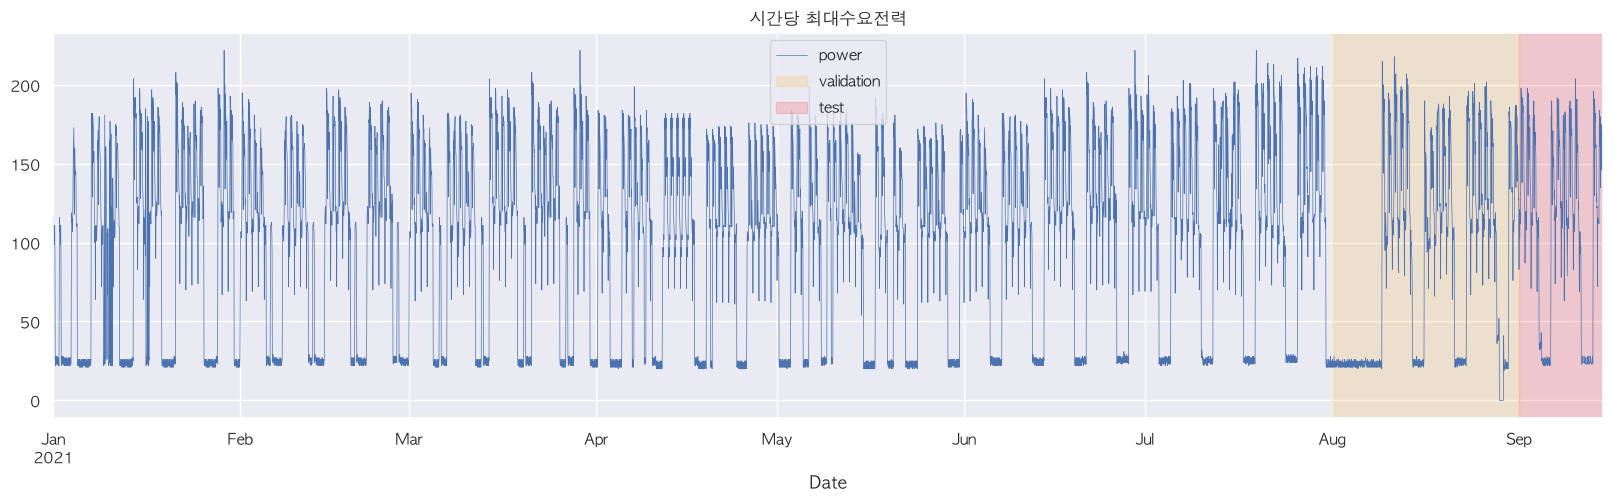

In [5]:
df = df.assign(power=df[DEMAND_COLS].max(axis=1))

ax = df["power"].plot(figsize=(20, 5), linewidth=0.5)
ax.axvspan(VAL_START, TEST_START, color="orange", alpha=0.15, label="validation")
ax.axvspan(TEST_START, df.index.max(), color="red", alpha=0.15, label="test")
ax.set_title("시간당 최대수요전력")
ax.legend()
plt.show()

## 3. Feature 구성 (X_t → y_(t+1))

각 행은 **예측 대상 시점 T = t+1** 을 index로 가진다. 행 T의 feature는 모두 T-1(=t) 이하의 정보로 만든다.

| 그룹 | Feature | 시점 |
|---|---|---|
| 전력 lag | `lag_k` = power(T-k), k ∈ {1,2,3,6,12,24,48,168} | `lag_1` = 현재 시점 t의 전력 |
| 현재 시간 15분 단위 | `q15_lag1`…`q60_lag1`, `avg_lag1` | t |
| 전력 rolling | 최근 3/24시간 평균, 24시간 최대·표준편차 | t-23 ~ t |
| 제조/환경 | 생산량, 기온, 풍속, 습도, 강수량, 전기요금, 공장인원, 인건비 | t (1시간 shift) |
| 달력 | hour, day_of_week, month, Weekend, Vacation | T (달력은 사전에 확정된 값이므로 누수가 아님) |

`날짜`, `시간`, `d`는 index/달력 feature와 중복이므로 사용하지 않는다.

In [6]:
EXOG_RENAME = {
    "생산량": "production",
    "기온": "temperature",
    "풍속": "wind_speed",
    "습도": "humidity",
    "강수량": "precipitation",
    "전기요금(계절)": "elec_price",
    "공장인원": "workers",
    "인건비": "labor_cost",
}
QUARTER_RENAME = {"15분": "q15", "30분": "q30", "45분": "q45", "60분": "q60", "평균": "avg"}

power = df["power"]
past_power = power.shift(1)  # t 시점까지의 전력

features = pd.concat(
    [
        pd.DataFrame({f"lag_{k}": power.shift(k) for k in LAG_HOURS}),
        df[list(QUARTER_RENAME)].shift(1).rename(columns=lambda c: f"{QUARTER_RENAME[c]}_lag1"),
        pd.DataFrame(
            {
                "roll_mean_3": past_power.rolling(3).mean(),
                "roll_mean_24": past_power.rolling(24).mean(),
                "roll_max_24": past_power.rolling(24).max(),
                "roll_std_24": past_power.rolling(24).std(),
            }
        ),
        df[list(EXOG_RENAME)].shift(1).rename(columns=EXOG_RENAME),
        pd.DataFrame(
            {
                "hour": df.index.hour,
                "day_of_week": df.index.dayofweek,
                "month": df.index.month,
                "Weekend": (df.index.dayofweek >= 5).astype(int),
                "Vacation": df.index.normalize().isin(HOLIDAYS).astype(int),
            },
            index=df.index,
        ),
    ],
    axis=1,
)

dataset = features.assign(target_power=power).dropna()
FEATURES = list(features.columns)
print(f"feature 수: {len(FEATURES)}")
print(f"lag_168 등으로 앞부분 {len(df) - len(dataset)}행 제거 → {len(dataset)}행")
dataset.head()

feature 수: 30
lag_168 등으로 앞부분 168행 제거 → 6000행


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,q15_lag1,q30_lag1,...,precipitation,elec_price,workers,labor_cost,hour,day_of_week,month,Weekend,Vacation,target_power
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,110.0,100.0,113.0,158.0,129.0,25.0,26.0,62.0,110.0,106.0,...,0.2,109.8,0.030534,1.5,0,4,1,0,0,64
2021-01-08 01:00:00,64.0,110.0,100.0,147.0,182.0,26.0,22.0,116.0,64.0,63.0,...,0.2,109.8,0.000000,1.5,1,4,1,0,0,110
2021-01-08 02:00:00,110.0,64.0,110.0,114.0,180.0,22.0,22.0,107.0,87.0,94.0,...,0.0,109.8,0.000000,1.5,2,4,1,0,0,111
2021-01-08 03:00:00,111.0,110.0,64.0,113.0,175.0,23.0,24.0,110.0,104.0,98.0,...,0.0,109.8,0.004866,1.5,3,4,1,0,0,105
2021-01-08 04:00:00,105.0,111.0,110.0,100.0,173.0,26.0,26.0,108.0,90.0,105.0,...,0.0,109.8,0.371859,1.5,4,4,1,0,0,110


### 3-1. 데이터 누수 점검 (feature)

- `lag_1`이 실제로 **직전 시점** 전력인지 index 기준으로 확인
- 어떤 feature도 target 시점 전력(`target_power`)과 동일하지 않은지 확인
- target과의 상관계수가 비정상적으로 높은 feature(|r| > 0.99)가 없는지 확인

In [7]:
prev_ts = dataset.index - pd.Timedelta(hours=1)
assert np.array_equal(dataset["lag_1"].to_numpy(), power.loc[prev_ts].to_numpy()), "lag_1 ≠ power(t)"
assert np.array_equal(dataset["q15_lag1"].to_numpy(), df.loc[prev_ts, "15분"].to_numpy())
assert np.array_equal(dataset["production"].to_numpy(), df.loc[prev_ts, "생산량"].to_numpy())

identical = [c for c in FEATURES if np.array_equal(dataset[c].to_numpy(), dataset["target_power"].to_numpy())]
assert not identical, f"target과 동일한 feature: {identical}"

corr_with_target = dataset[FEATURES].corrwith(dataset["target_power"]).abs().sort_values(ascending=False)
assert (corr_with_target < 0.99).all(), corr_with_target.head()
print("누수 점검 통과 — target과 |상관계수| 상위 feature:")
corr_with_target.head(8).round(3)

누수 점검 통과 — target과 |상관계수| 상위 feature:


q60_lag1       0.933
lag_1          0.919
avg_lag1       0.906
q45_lag1       0.903
roll_mean_3    0.894
q30_lag1       0.872
q15_lag1       0.871
lag_2          0.862
dtype: float64

## 4. Train / Validation / Test 분리 (시간순)

| 구간 | 기간 | 용도 |
|---|---|---|
| Train | 2021-01-08 ~ 2021-07-31 | 모델 학습, **피크 임계값 계산** |
| Validation | 2021-08-01 ~ 2021-08-31 | hyperparameter 선택, 분류 threshold 선택 |
| Test | 2021-09-01 ~ 2021-09-14 | 최종 평가 (1회) |

Validation 8월에는 하계 휴무 주간(8/2~8/8, 전력 최대 27)이 포함되어 있다.

In [8]:
train_df = dataset.loc[dataset.index < VAL_START]
val_df = dataset.loc[(dataset.index >= VAL_START) & (dataset.index < TEST_START)]
test_df = dataset.loc[dataset.index >= TEST_START]

assert train_df.index.max() < val_df.index.min() <= val_df.index.max() < test_df.index.min()
assert len(train_df) + len(val_df) + len(test_df) == len(dataset)

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:<11} {part.index.min()} ~ {part.index.max()}  n={len(part)}")

Train       2021-01-08 00:00:00 ~ 2021-07-31 23:00:00  n=4920
Validation  2021-08-01 00:00:00 ~ 2021-08-31 23:00:00  n=744
Test        2021-09-01 00:00:00 ~ 2021-09-14 23:00:00  n=336


## 5. Target 정의 — 피크 임계값 (train only)

`peak_threshold = quantile(train target_power, PEAK_QUANTILE)` 를 **train 구간만으로** 계산하고,
같은 값을 validation/test 라벨링에 그대로 적용한다.

In [9]:
peak_threshold = float(train_df["target_power"].quantile(PEAK_QUANTILE))
print(f"PEAK_QUANTILE = {PEAK_QUANTILE} → peak threshold = {peak_threshold:.1f} (train 구간에서만 계산)")

def make_xy(part: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    y = (part["target_power"] >= peak_threshold).astype(int).rename("label")
    return part[FEATURES], y

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

label_summary = pd.DataFrame(
    {
        "samples": [len(y_train), len(y_val), len(y_test)],
        "positive": [y_train.sum(), y_val.sum(), y_test.sum()],
        "negative": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    },
    index=["Train", "Validation", "Test"],
).assign(positive_ratio=lambda t: (t["positive"] / t["samples"]).round(4))
label_summary

PEAK_QUANTILE = 0.9 → peak threshold = 179.0 (train 구간에서만 계산)


,samples,positive,negative,positive_ratio
Train,4920,505,4415,0.1026
Validation,744,101,643,0.1358
Test,336,47,289,0.1399


## 6. 클래스 불균형 확인 / `scale_pos_weight`

`scale_pos_weight = negative_count / positive_count` (train 기준)

In [10]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count
print(f"negative_count = {negative_count}, positive_count = {positive_count}")
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

negative_count = 4415, positive_count = 505
scale_pos_weight = 8.743


## 7. 평가 함수

불균형 문제이므로 **F1**과 **PR-AUC(average precision)** 를 주요 지표로 본다.
확률은 반드시 `predict_proba(X)[:, 1]`을 사용한다.

In [11]:
def evaluate(y_true, proba, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


def threshold_sweep(y_true, proba, grid=CLASS_THRESHOLD_GRID) -> pd.DataFrame:
    return pd.DataFrame([evaluate(y_true, proba, t) for t in grid]).set_index("threshold")


def best_threshold(y_true, proba) -> float:
    sweep = threshold_sweep(y_true, proba)
    return float(sweep["F1"].idxmax())

## 8. Reference: Persistence baseline

모델 없이 "현재 전력(`lag_1`)이 피크 임계값 이상이면 다음 시점도 피크"라고 예측하는 규칙.
학습 모델이 이 단순 규칙보다 나은지 확인하기 위한 기준선이다 (score = `lag_1`).

In [12]:
persistence_val = evaluate(y_val, X_val["lag_1"].to_numpy(), threshold=peak_threshold)
persistence_test = evaluate(y_test, X_test["lag_1"].to_numpy(), threshold=peak_threshold)
pd.DataFrame([persistence_val, persistence_test], index=["Validation", "Test"]).round(4)

,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
Validation,179.0,0.8978,0.6238,0.6238,0.6238,0.9255,0.6256,63,38,38,605
Test,179.0,0.8452,0.4468,0.4468,0.4468,0.8623,0.5295,21,26,26,263


## 9. Baseline — RandomForestClassifier

XGBoost와 **동일한 feature, 동일한 train/validation/test**를 사용한다.
공정한 비교를 위해 RF도 validation PR-AUC 기준으로 소규모 grid search를 수행한다.

In [13]:
rf_grid = [
    {"max_depth": d, "min_samples_leaf": leaf, "class_weight": cw}
    for d in [None, 10, 20]
    for leaf in [1, 5, 10]
    for cw in [None, "balanced_subsample"]
]

rf_results = []
for params in rf_grid:
    rf = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1, **params)
    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_val)[:, 1]
    rf_results.append({**params, "val_PR-AUC": average_precision_score(y_val, proba), "val_ROC-AUC": roc_auc_score(y_val, proba)})

rf_search = pd.DataFrame(rf_results).sort_values("val_PR-AUC", ascending=False)
best_rf_params = rf_search.iloc[0][["max_depth", "min_samples_leaf", "class_weight"]].to_dict()
best_rf_params = {
    "max_depth": None if pd.isna(best_rf_params["max_depth"]) else int(best_rf_params["max_depth"]),
    "min_samples_leaf": int(best_rf_params["min_samples_leaf"]),
    "class_weight": best_rf_params["class_weight"] if isinstance(best_rf_params["class_weight"], str) else None,
}
print("best RF params (validation PR-AUC):", best_rf_params)
rf_search.head(5).round(4)

best RF params (validation PR-AUC): {'max_depth': None, 'min_samples_leaf': 5, 'class_weight': 'balanced_subsample'}


,max_depth,min_samples_leaf,class_weight,val_PR-AUC,val_ROC-AUC
3,NaN,5,balanced_subsample,0.8704,0.9812
15,20.0,5,balanced_subsample,0.8704,0.9812
4,NaN,10,NaN,0.8693,0.9791
16,20.0,10,NaN,0.8693,0.9791
8,10.0,5,NaN,0.8684,0.9786


In [14]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train, y_train)

rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
rf_threshold = best_threshold(y_val, rf_val_proba)
print(f"RF classification threshold (validation F1 최대): {rf_threshold}")

RF classification threshold (validation F1 최대): 0.5


## 10. XGBoost — `scale_pos_weight` 적용 전/후 비교

과도한 튜닝 없이 reasonable한 기본값으로 시작한다. 두 모델은 `scale_pos_weight`만 다르다.

In [15]:
XGB_BASE_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,
}

xgb_no_spw = XGBClassifier(**XGB_BASE_PARAMS, scale_pos_weight=1.0).fit(X_train, y_train)
xgb_spw = XGBClassifier(**XGB_BASE_PARAMS, scale_pos_weight=scale_pos_weight).fit(X_train, y_train)

spw_compare = pd.DataFrame(
    {
        "no scale_pos_weight": evaluate(y_val, xgb_no_spw.predict_proba(X_val)[:, 1]),
        f"scale_pos_weight={scale_pos_weight:.2f}": evaluate(y_val, xgb_spw.predict_proba(X_val)[:, 1]),
    }
).T
print("Validation, threshold = 0.5")
spw_compare.round(4)

Validation, threshold = 0.5


,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
no scale_pos_weight,0.5,0.9395,0.8043,0.7327,0.7668,0.9777,0.8530,74.0,18.0,27.0,625.0
scale_pos_weight=8.74,0.5,0.9476,0.7672,0.8812,0.8203,0.9782,0.8497,89.0,27.0,12.0,616.0


`scale_pos_weight`는 양성 클래스의 loss 가중치를 키워 **확률 분포를 위로 이동**시킨다.
따라서 threshold 0.5 기준에서는 Recall↑ / Precision↓ 경향이 나타나고,
순위 기반 지표(ROC-AUC, PR-AUC)의 변화는 상대적으로 작다. 최종적으로는 두 설정 모두 아래 grid에 포함하고
threshold를 validation에서 따로 맞춘다.

## 11. XGBoost hyperparameter tuning (validation only)

선택 기준: **validation PR-AUC** (threshold에 독립적인 지표). Test는 사용하지 않는다.

In [16]:
xgb_grid = [
    {
        "n_estimators": n,
        "max_depth": d,
        "learning_rate": lr,
        "min_child_weight": mcw,
        "scale_pos_weight": spw,
    }
    for n in [200, 500]
    for d in [3, 4, 6]
    for lr in [0.03, 0.1]
    for mcw in [1, 5]
    for spw in [1.0, scale_pos_weight]
]

tune_base = {k: v for k, v in XGB_BASE_PARAMS.items() if k not in xgb_grid[0]}
xgb_results = []
for params in xgb_grid:
    model = XGBClassifier(**tune_base, **params).fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    xgb_results.append({**params, "val_PR-AUC": average_precision_score(y_val, proba), "val_ROC-AUC": roc_auc_score(y_val, proba)})

xgb_search = pd.DataFrame(xgb_results).sort_values("val_PR-AUC", ascending=False)
best_xgb_params = {
    k: (float(v) if k in {"learning_rate", "scale_pos_weight"} else int(v))
    for k, v in xgb_search.iloc[0][list(xgb_grid[0])].items()
}
print(f"{len(xgb_grid)}개 조합 탐색 — best params:", best_xgb_params)
xgb_search.head(10).round(4)

48개 조합 탐색 — best params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 1, 'scale_pos_weight': 8.742574257425742}


,n_estimators,max_depth,learning_rate,min_child_weight,scale_pos_weight,val_PR-AUC,val_ROC-AUC
33,500,4,0.03,1,8.7426,0.8696,0.9811
5,200,3,0.10,1,8.7426,0.8693,0.9792
9,200,4,0.03,1,8.7426,0.8604,0.9786
29,500,3,0.10,1,8.7426,0.8579,0.9785
35,500,4,0.03,5,8.7426,0.8555,0.9797
27,500,3,0.03,5,8.7426,0.8510,0.9773
11,200,4,0.03,5,8.7426,0.8506,0.9779
28,500,3,0.10,1,1.0000,0.8495,0.9768
25,500,3,0.03,1,8.7426,0.8494,0.9765
12,200,4,0.10,1,1.0000,0.8494,0.9758


In [17]:
xgb_model = XGBClassifier(**tune_base, **best_xgb_params).fit(X_train, y_train)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

## 12. Classification threshold tuning (validation)

0.5 고정 대신 validation에서 threshold를 바꿔가며 F1을 비교하고, F1이 최대인 threshold를 **Test에 그대로 적용**한다.

XGBoost best threshold (validation F1) = 0.65
RF      best threshold (validation F1) = 0.5


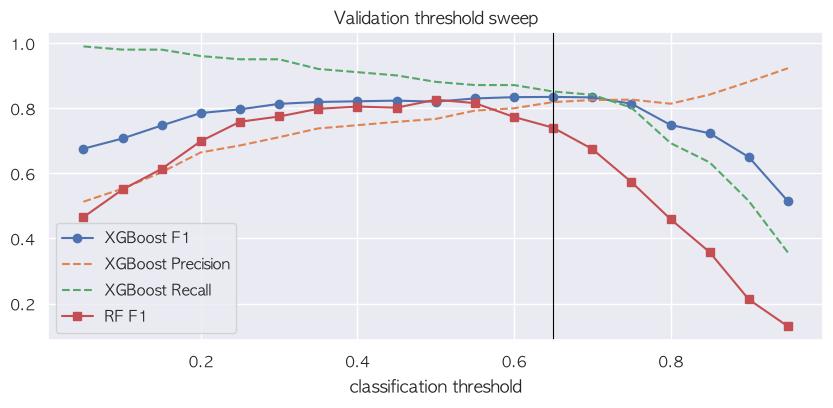

,Precision,Recall,F1,TP,FP,FN
threshold,,,,,,
0.05,0.5128,0.9901,0.6757,100,95,1
0.10,0.5531,0.9802,0.7071,99,80,2
0.15,0.6037,0.9802,0.7472,99,65,2
0.20,0.6644,0.9604,0.7854,97,49,4
0.25,0.6857,0.9505,0.7967,96,44,5
0.30,0.7111,0.9505,0.8136,96,39,5
0.35,0.7381,0.9208,0.8194,93,33,8
0.40,0.7480,0.9109,0.8214,92,31,9
0.45,0.7583,0.9010,0.8235,91,29,10


In [18]:
xgb_sweep = threshold_sweep(y_val, xgb_val_proba)
rf_sweep = threshold_sweep(y_val, rf_val_proba)
xgb_threshold = float(xgb_sweep["F1"].idxmax())
print(f"XGBoost best threshold (validation F1) = {xgb_threshold}")
print(f"RF      best threshold (validation F1) = {rf_threshold}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xgb_sweep.index, xgb_sweep["F1"], marker="o", label="XGBoost F1")
ax.plot(xgb_sweep.index, xgb_sweep["Precision"], linestyle="--", label="XGBoost Precision")
ax.plot(xgb_sweep.index, xgb_sweep["Recall"], linestyle="--", label="XGBoost Recall")
ax.plot(rf_sweep.index, rf_sweep["F1"], marker="s", label="RF F1")
ax.axvline(xgb_threshold, color="black", linewidth=0.8)
ax.set_xlabel("classification threshold")
ax.set_title("Validation threshold sweep")
ax.legend()
plt.show()

xgb_sweep[["Precision", "Recall", "F1", "TP", "FP", "FN"]].round(4)

## 13. Test 평가 (최종 1회)

Validation에서 고정한 모델·threshold를 그대로 적용한다.

In [19]:
test_rows = {
    "Persistence (lag_1 ≥ peak)": persistence_test,
    "Random Forest @0.5": evaluate(y_test, rf_test_proba, 0.5),
    f"Random Forest @{rf_threshold}": evaluate(y_test, rf_test_proba, rf_threshold),
    "XGBoost default (no spw) @0.5": evaluate(y_test, xgb_no_spw.predict_proba(X_test)[:, 1], 0.5),
    "XGBoost default (spw) @0.5": evaluate(y_test, xgb_spw.predict_proba(X_test)[:, 1], 0.5),
    "XGBoost tuned @0.5": evaluate(y_test, xgb_test_proba, 0.5),
    f"XGBoost tuned @{xgb_threshold}": evaluate(y_test, xgb_test_proba, xgb_threshold),
}
test_report = pd.DataFrame(test_rows).T
test_report.index.name = "Model"
test_report.round(4)

,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
Model,,,,,,,,,,,
Persistence (lag_1 ≥ peak),179.00,0.8452,0.4468,0.4468,0.4468,0.8623,0.5295,21.0,26.0,26.0,263.0
Random Forest @0.5,0.50,0.9048,0.6190,0.8298,0.7091,0.9553,0.7371,39.0,24.0,8.0,265.0
XGBoost default (no spw) @0.5,0.50,0.9048,0.6471,0.7021,0.6735,0.9561,0.7417,33.0,18.0,14.0,271.0
XGBoost default (spw) @0.5,0.50,0.8988,0.5915,0.8936,0.7119,0.9567,0.7473,42.0,29.0,5.0,260.0
XGBoost tuned @0.5,0.50,0.9018,0.6000,0.8936,0.7179,0.9533,0.7113,42.0,28.0,5.0,261.0
XGBoost tuned @0.65,0.65,0.8988,0.6066,0.7872,0.6852,0.9533,0.7113,37.0,24.0,10.0,265.0


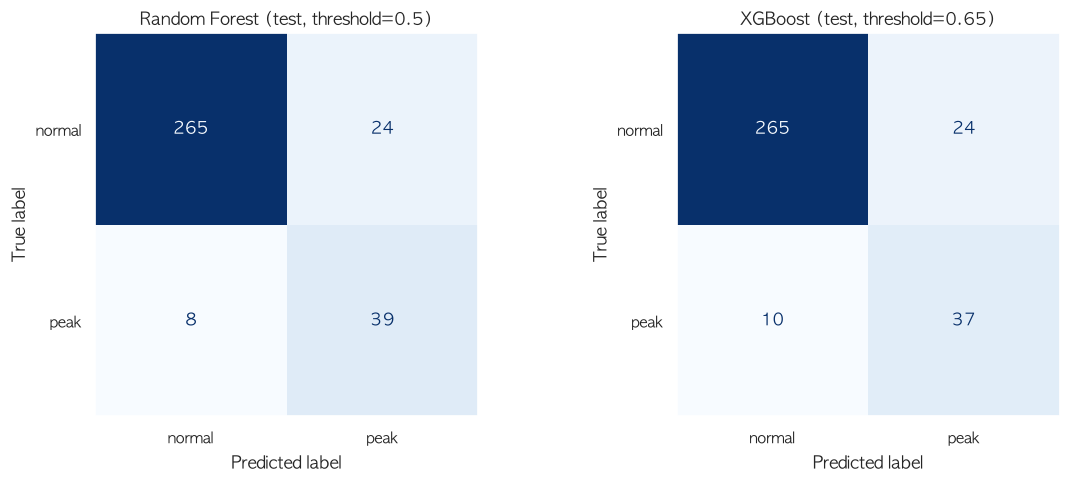

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, proba, thr) in zip(
    axes,
    [("Random Forest", rf_test_proba, rf_threshold), ("XGBoost", xgb_test_proba, xgb_threshold)],
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, (proba >= thr).astype(int), labels=[0, 1]),
        display_labels=["normal", "peak"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} (test, threshold={thr})")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 14. Random Forest vs XGBoost 비교표

In [21]:
METRIC_COLS = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

model_comparison = pd.DataFrame(
    [
        {"Model": "Random Forest", "threshold": rf_threshold, **{m: test_rows[f"Random Forest @{rf_threshold}"][m] for m in METRIC_COLS}},
        {"Model": "XGBoost", "threshold": xgb_threshold, **{m: test_rows[f"XGBoost tuned @{xgb_threshold}"][m] for m in METRIC_COLS}},
    ]
).set_index("Model")

model_comparison.round(4)

,threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.50,0.6190,0.8298,0.7091,0.9553,0.7371
XGBoost,0.65,0.6066,0.7872,0.6852,0.9533,0.7113


In [22]:
diff = (model_comparison.loc["XGBoost", METRIC_COLS] - model_comparison.loc["Random Forest", METRIC_COLS]).astype(float)
for metric, delta in diff.items():
    winner = "XGBoost" if delta > 0 else ("Random Forest" if delta < 0 else "동일")
    print(f"{metric:<9} XGB - RF = {delta:+.4f}  → {winner}")

rf_cm = test_rows[f"Random Forest @{rf_threshold}"]
xgb_cm = test_rows[f"XGBoost tuned @{xgb_threshold}"]
print(f"\nTest 양성 {int(y_test.sum())}건 중 — RF: TP {rf_cm['TP']}, FP {rf_cm['FP']}, FN {rf_cm['FN']} | "
      f"XGB: TP {xgb_cm['TP']}, FP {xgb_cm['FP']}, FN {xgb_cm['FN']}")

Precision XGB - RF = -0.0125  → Random Forest
Recall    XGB - RF = -0.0426  → Random Forest
F1        XGB - RF = -0.0239  → Random Forest
ROC-AUC   XGB - RF = -0.0021  → Random Forest
PR-AUC    XGB - RF = -0.0258  → Random Forest

Test 양성 47건 중 — RF: TP 39, FP 24, FN 8 | XGB: TP 37, FP 24, FN 10


### 14-1. 결과 해석 (`PEAK_QUANTILE = 0.90`, `SEED = 42` 실행 기준)

- **Validation에서는 두 모델이 사실상 동률**이다. PR-AUC는 RF 0.8704, XGBoost 0.8696으로 차이가 0.001 미만이다.
- **Test에서는 RF가 모든 지표에서 소폭 앞선다.** F1은 0.7091 vs 0.6852, PR-AUC는 0.7371 vs 0.7113이다.
  다만 양성이 47건뿐이라, 피크 1건 차이가 Recall 약 0.02에 해당한다. 실제 차이는 TP 2건(39 vs 37)과 FN 2건(8 vs 10)으로, 통계적으로 유의한 격차라고 보기 어렵다.
- **XGBoost의 threshold 0.65는 validation에서는 최적이었지만 test에서는 불리했다.**
  같은 모델을 0.5로 쓰면 test F1이 0.7179가 된다. 이 값은 test를 보고 고른 것이므로 **최종 성능으로 채택하지 않는다**.
  8월 validation 구간에는 하계 휴무 주간이 있어 9월과 확률 분포가 달라진 것으로 보인다.
  또한 증강 데이터라 이전 달의 구간이 그대로 복사된 부분이 있다. 시간당 4개 값 조합이 이전 달에 존재하는 비율이 8월 27%, 9월 19%라서, validation 점수가 test보다 약간 낙관적으로 나온다.
- `scale_pos_weight` 적용 여부(threshold 0.5)를 보면 Recall은 올라가고(0.70 → 0.89), Precision은 내려간다(0.65 → 0.59).
  반면 ROC-AUC와 PR-AUC 변화는 ±0.006 이내다. 즉 순위 품질보다 **확률의 보정(calibration) 위치**를 바꾸는 효과가 크다.
- 두 모델 모두 persistence 규칙(F1 0.4468, PR-AUC 0.5295)보다 확실히 높다. 따라서 "현재 전력이 높으면 다음도 높다"는 단순 규칙 이상을 학습한 것이다.

## 15. 결과 저장

- `results/xgboost_predictions.csv`: Test 구간 XGBoost 예측 (`Date, actual_label, predicted_label, risk_probability, actual_power`)
- `results/model_comparison.csv`: Test 평가표 (persistence, RF, XGBoost 변형 전체)
- `models/xgboost_classifier.json`: 학습된 XGBoost 모델 + `xgboost_classifier_meta.json`(임계값, feature 목록)

후속 notebook(`04_catboost.ipynb`)이 **같은 데이터셋·분할·baseline 결과를 재학습 없이** 쓸 수 있도록 다음도 저장한다.

- `results/peak_dataset.csv`: feature + `target_power` + `split`(train/validation/test)
- `results/peak_baseline_probabilities.csv`: validation/test 구간의 RF·XGBoost 피크 위험 확률
- `results/peak_experiment_meta.json`: 피크 임계값, 분할 경계, feature 목록, 모델별 분류 threshold

In [23]:
xgb_predictions = pd.DataFrame(
    {
        "Date": X_test.index,
        "actual_label": y_test.to_numpy(),
        "predicted_label": (xgb_test_proba >= xgb_threshold).astype(int),
        "risk_probability": xgb_test_proba,
        "actual_power": test_df["target_power"].to_numpy(),
    }
)
xgb_predictions.to_csv(RESULTS_DIR / "xgboost_predictions.csv", index=False)

test_report.to_csv(RESULTS_DIR / "model_comparison.csv")

xgb_model.save_model(MODELS_DIR / "xgboost_classifier.json")
(MODELS_DIR / "xgboost_classifier_meta.json").write_text(
    json.dumps(
        {
            "peak_quantile": PEAK_QUANTILE,
            "peak_threshold": peak_threshold,
            "classification_threshold": xgb_threshold,
            "params": best_xgb_params,
            "features": FEATURES,
            "train_period": [str(train_df.index.min()), str(train_df.index.max())],
        },
        ensure_ascii=False,
        indent=2,
    )
)

split_label = pd.Series("train", index=dataset.index).mask(dataset.index >= VAL_START, "validation").mask(dataset.index >= TEST_START, "test")
dataset.assign(split=split_label).to_csv(RESULTS_DIR / "peak_dataset.csv")

pd.concat(
    [
        pd.DataFrame({"split": "validation", "rf_probability": rf_val_proba, "xgb_probability": xgb_val_proba}, index=X_val.index),
        pd.DataFrame({"split": "test", "rf_probability": rf_test_proba, "xgb_probability": xgb_test_proba}, index=X_test.index),
    ]
).to_csv(RESULTS_DIR / "peak_baseline_probabilities.csv")

(RESULTS_DIR / "peak_experiment_meta.json").write_text(
    json.dumps(
        {
            "peak_quantile": PEAK_QUANTILE,
            "peak_threshold": peak_threshold,
            "val_start": str(VAL_START),
            "test_start": str(TEST_START),
            "features": FEATURES,
            "rf_params": best_rf_params,
            "rf_threshold": rf_threshold,
            "xgb_params": best_xgb_params,
            "xgb_threshold": xgb_threshold,
        },
        ensure_ascii=False,
        indent=2,
    )
)
xgb_predictions.head()

,Date,actual_label,predicted_label,risk_probability,actual_power
0,2021-09-01 00:00:00,0,0,0.002481,83
1,2021-09-01 01:00:00,0,0,0.000349,117
2,2021-09-01 02:00:00,0,0,0.000477,121
3,2021-09-01 03:00:00,0,0,0.000568,103
4,2021-09-01 04:00:00,0,0,0.000394,119


### 15-1. Test 구간 시각화 — 실제 전력과 피크 위험 확률

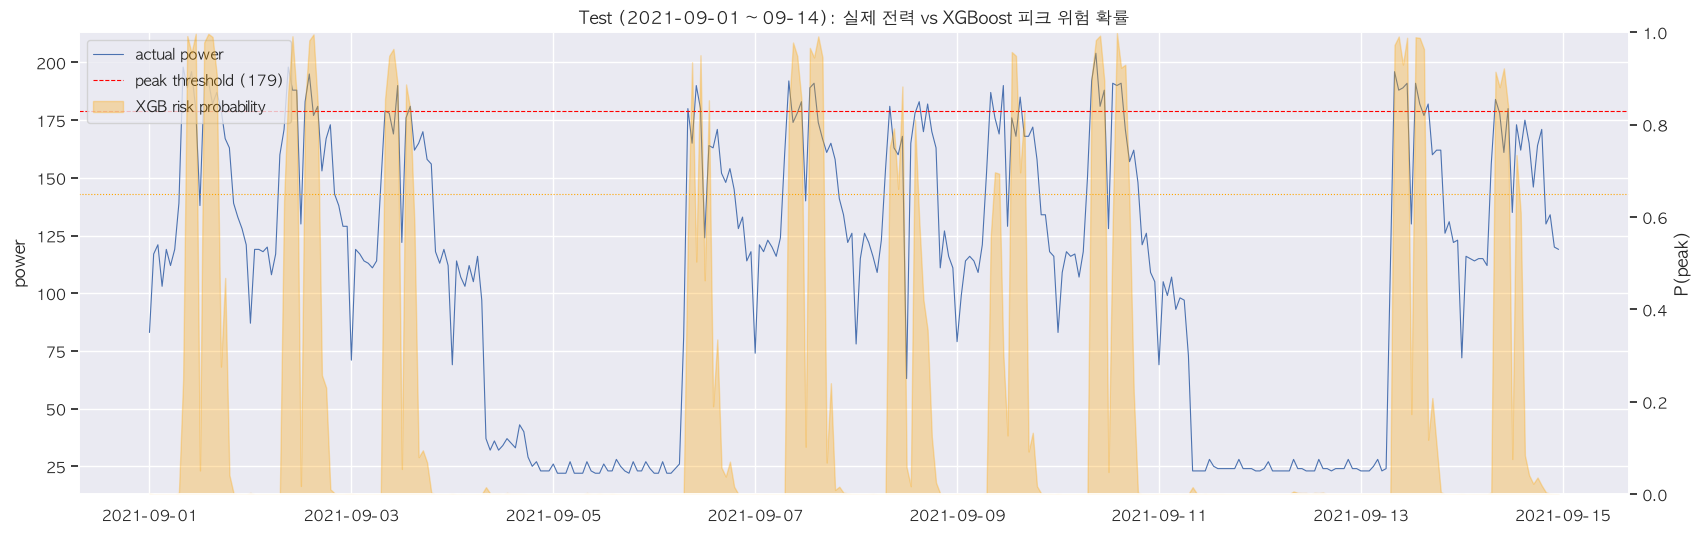

In [24]:
fig, ax1 = plt.subplots(figsize=(20, 6))
ax1.plot(xgb_predictions["Date"], xgb_predictions["actual_power"], linewidth=0.8, label="actual power")
ax1.axhline(peak_threshold, color="red", linestyle="--", linewidth=0.8, label=f"peak threshold ({peak_threshold:.0f})")
ax1.set_ylabel("power")

ax2 = ax1.twinx()
ax2.fill_between(xgb_predictions["Date"], xgb_predictions["risk_probability"], color="orange", alpha=0.3, label="XGB risk probability")
ax2.axhline(xgb_threshold, color="orange", linestyle=":", linewidth=0.8)
ax2.set_ylim(0, 1)
ax2.set_ylabel("P(peak)")
ax2.grid(False)

lines = ax1.get_legend_handles_labels()
lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines[0] + lines2[0], lines[1] + lines2[1], loc="upper left")
ax1.set_title("Test (2021-09-01 ~ 09-14): 실제 전력 vs XGBoost 피크 위험 확률")
plt.show()

## 16. Feature Importance / SHAP

- XGBoost `gain` 기반 global importance
- SHAP(TreeExplainer)으로 test 구간 피크 위험 확률(log-odds)에 대한 feature 기여도 분석

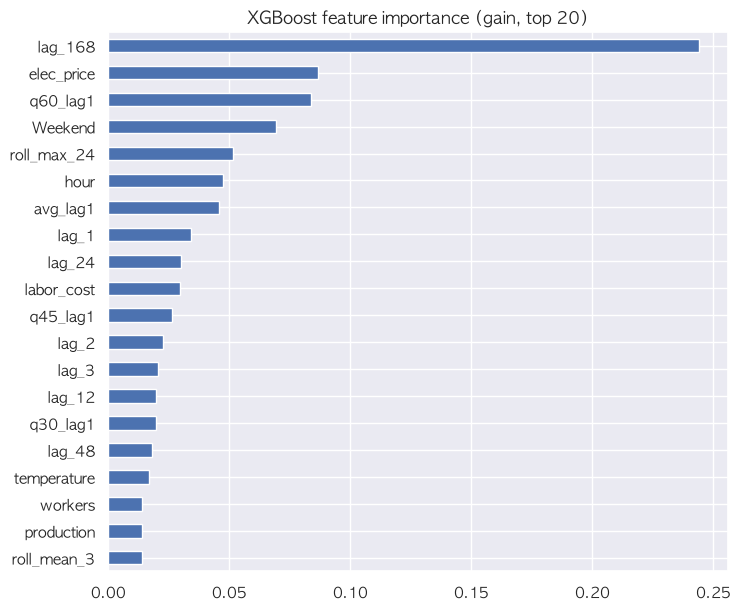

,gain,gain_ratio
lag_168,168.1217,0.2439
elec_price,59.5993,0.0865
q60_lag1,57.7196,0.0837
Weekend,47.7392,0.0693
roll_max_24,35.6020,0.0517
hour,32.7559,0.0475
avg_lag1,31.5771,0.0458
lag_1,23.5670,0.0342
lag_24,20.8253,0.0302
labor_cost,20.3353,0.0295


In [25]:
gain = xgb_model.get_booster().get_score(importance_type="gain")
feature_importance = (
    pd.Series({f: gain.get(f, 0.0) for f in FEATURES}, name="gain")
    .sort_values(ascending=False)
    .to_frame()
    .assign(gain_ratio=lambda t: t["gain"] / t["gain"].sum())
)

fig, ax = plt.subplots(figsize=(8, 7))
feature_importance["gain_ratio"].head(20).iloc[::-1].plot.barh(ax=ax)
ax.set_title("XGBoost feature importance (gain, top 20)")
plt.show()

feature_importance.head(10).round(4)

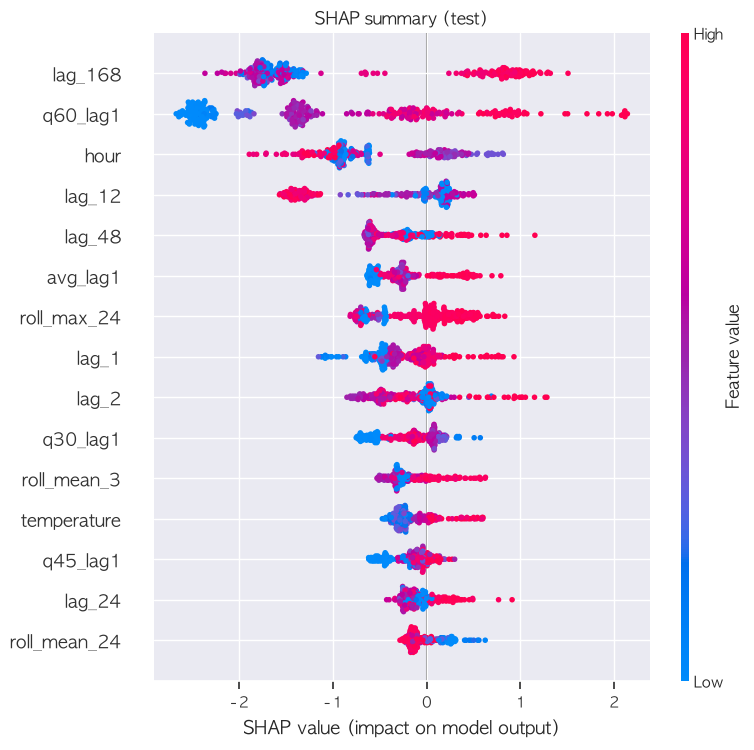

,mean_abs_shap
lag_168,1.3953
q60_lag1,1.3536
hour,0.7192
lag_12,0.6209
lag_48,0.3777
avg_lag1,0.3741
roll_max_24,0.3335
lag_1,0.3284
lag_2,0.2990
q30_lag1,0.2677


In [26]:
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer(X_test)

    shap.summary_plot(shap_values, X_test, max_display=15, show=False)
    plt.title("SHAP summary (test)")
    plt.show()

    shap_importance = (
        pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURES, name="mean_abs_shap")
        .sort_values(ascending=False)
    )
    display(shap_importance.head(10).round(4).to_frame())
else:
    print("SHAP 미설치 — `pip install shap` (requirements.txt: shap)")

**해석**
- `lag_168`(1주 전 같은 시각)은 gain과 SHAP 모두에서 1위다. 공장의 **주간 가동 패턴**이 피크 위험을 가장 강하게 설명한다.
- 이어서 `q60_lag1`, `avg_lag1`, `lag_1`(현재 시간의 전력 수준)과 `hour`(가동 시간대)가 중요하다.
- `elec_price`는 하루 단위의 계절 요금이라, 사실상 **계절 proxy**로 작동한다. `Weekend`, `labor_cost`(주간/야간 단가)도 가동 여부를 간접적으로 나타낸다.
- 생산량·기상 변수는 상위 10위 밖이다. 이 데이터에서는 전력 이력과 달력 정보가 외생변수보다 설명력이 크다.

## 17. 오류 사례 분석 — XGBoost vs Random Forest

Test 구간에서 두 모델(각자의 validation threshold 적용)의 예측을 비교한다.

In [27]:
case_cols = ["actual_power", "lag_1", "lag_24", "hour", "day_of_week", "production", "workers", "temperature"]
cases = (
    X_test.assign(actual_power=test_df["target_power"], actual_label=y_test)
    .assign(
        xgb_prob=xgb_test_proba,
        rf_prob=rf_test_proba,
        xgb_pred=(xgb_test_proba >= xgb_threshold).astype(int),
        rf_pred=(rf_test_proba >= rf_threshold).astype(int),
    )
)

xgb_only_hit = cases.query("actual_label == 1 and xgb_pred == 1 and rf_pred == 0")
rf_only_hit = cases.query("actual_label == 1 and rf_pred == 1 and xgb_pred == 0")
xgb_only_fp = cases.query("actual_label == 0 and xgb_pred == 1 and rf_pred == 0")
rf_only_fp = cases.query("actual_label == 0 and rf_pred == 1 and xgb_pred == 0")

print(f"XGBoost만 맞힌 피크(RF는 놓침): {len(xgb_only_hit)}건")
print(f"RF만 맞힌 피크(XGBoost는 놓침): {len(rf_only_hit)}건")
print(f"XGBoost만 낸 오탐(FP): {len(xgb_only_fp)}건 | RF만 낸 오탐(FP): {len(rf_only_fp)}건")
xgb_only_hit[case_cols + ["xgb_prob", "rf_prob"]].round(3)

XGBoost만 맞힌 피크(RF는 놓침): 2건
RF만 맞힌 피크(XGBoost는 놓침): 4건
XGBoost만 낸 오탐(FP): 3건 | RF만 낸 오탐(FP): 3건


,actual_power,lag_1,lag_24,hour,day_of_week,production,workers,temperature,xgb_prob,rf_prob
Date,,,,,,,,,,
2021-09-07 08:00:00,192,160.0,180.0,8,1,548.0,0.977,21.1,0.829,0.465
2021-09-09 15:00:00,185,168.0,183.0,15,3,2666.0,4.033,26.8,0.697,0.373


In [28]:
rf_only_hit[case_cols + ["xgb_prob", "rf_prob"]].round(3)

,actual_power,lag_1,lag_24,hour,day_of_week,production,workers,temperature,xgb_prob,rf_prob
Date,,,,,,,,,,
2021-09-01 17:00:00,180,187.0,139.0,17,2,1460.0,2.080,22.6,0.276,0.563
2021-09-06 08:00:00,180,81.0,27.0,8,0,0.0,0.000,22.3,0.565,0.666
2021-09-09 08:00:00,187,152.0,181.0,8,3,2056.0,3.705,20.9,0.558,0.543
2021-09-10 13:00:00,191,128.0,176.0,13,4,480.0,1.032,24.2,0.586,0.792


### 17-1. XGBoost False Positive (확률 높은 순)

In [29]:
xgb_fp = cases.query("actual_label == 0 and xgb_pred == 1").sort_values("xgb_prob", ascending=False)
print(f"XGBoost FP {len(xgb_fp)}건 (peak threshold = {peak_threshold:.0f})")
xgb_fp[case_cols + ["xgb_prob", "rf_prob"]].head(8).round(3)

XGBoost FP 24건 (peak threshold = 179)


,actual_power,lag_1,lag_24,hour,day_of_week,production,workers,temperature,xgb_prob,rf_prob
Date,,,,,,,,,,
2021-09-02 15:00:00,177,195.0,182.0,15,3,1151.0,1.499,23.0,0.995,0.940
2021-09-07 15:00:00,174,191.0,171.0,15,1,1395.0,1.916,26.5,0.991,0.903
2021-09-07 09:00:00,174,192.0,165.0,9,1,1236.0,1.784,21.7,0.978,0.760
2021-09-03 10:00:00,169,178.0,188.0,10,4,1005.0,1.467,21.0,0.964,0.821
2021-09-13 15:00:00,177,182.0,24.0,15,0,1018.0,1.416,24.2,0.964,0.881
2021-09-09 13:00:00,176,129.0,165.0,13,3,194.0,0.438,26.7,0.957,0.810
2021-09-03 09:00:00,178,179.0,198.0,9,4,706.0,1.041,20.4,0.949,0.803
2021-09-09 14:00:00,168,176.0,178.0,14,3,1542.0,2.258,26.4,0.949,0.693


### 17-2. XGBoost False Negative (확률 낮은 순)

In [30]:
xgb_fn = cases.query("actual_label == 1 and xgb_pred == 0").sort_values("xgb_prob")
print(f"XGBoost FN {len(xgb_fn)}건")
xgb_fn[case_cols + ["xgb_prob", "rf_prob"]].head(8).round(3)

XGBoost FN 10건


,actual_power,lag_1,lag_24,hour,day_of_week,production,workers,temperature,xgb_prob,rf_prob
Date,,,,,,,,,,
2021-09-13 16:00:00,182,177.0,24.0,16,0,1138.0,1.699,23.7,0.118,0.431
2021-09-01 08:00:00,198,139.0,177.0,8,2,1747.0,3.536,21.3,0.248,0.403
2021-09-01 17:00:00,180,187.0,139.0,17,2,1460.0,2.080,22.6,0.276,0.563
2021-09-09 11:00:00,190,169.0,168.0,11,3,1248.0,2.010,24.8,0.304,0.285
2021-09-08 17:00:00,182,170.0,161.0,17,2,513.0,0.775,23.9,0.356,0.366
2021-09-06 10:00:00,190,165.0,22.0,10,0,976.0,1.552,23.6,0.504,0.294
2021-09-09 08:00:00,187,152.0,181.0,8,3,2056.0,3.705,20.9,0.558,0.543
2021-09-06 08:00:00,180,81.0,27.0,8,0,0.0,0.000,22.3,0.565,0.666


In [31]:
def describe_errors(frame: pd.DataFrame, name: str) -> None:
    if frame.empty:
        print(f"{name}: 없음")
        return
    near = (frame["actual_power"] - peak_threshold).abs().le(10).mean()
    print(
        f"{name}: {len(frame)}건 | 평균 실제전력 {frame['actual_power'].mean():.1f} "
        f"(임계값 ±10 이내 {near:.0%}) | 평균 lag_1 {frame['lag_1'].mean():.1f} | "
        f"주요 시간대 {frame['hour'].value_counts().head(3).to_dict()}"
    )

describe_errors(xgb_fp, "XGBoost FP")
describe_errors(xgb_fn, "XGBoost FN")

XGBoost FP: 24건 | 평균 실제전력 171.2 (임계값 ±10 이내 62%) | 평균 lag_1 170.9 | 주요 시간대 {9: 6, 10: 5, 13: 4}
XGBoost FN: 10건 | 평균 실제전력 186.3 (임계값 ±10 이내 60%) | 평균 lag_1 154.6 | 주요 시간대 {8: 3, 17: 2, 16: 1}


### 17-3. 오류 사례 해석 (`SEED = 42` 실행 기준)

**XGBoost만 맞힌 피크 (2건)**: 09-07 08시, 09-09 15시.
두 경우 모두 `lag_1`(160, 168)은 임계값보다 낮았지만 **전일 같은 시각(`lag_24` 180, 183)이 피크**였다.
XGBoost는 일/주 주기 lag를 더 강하게 반영해 확률을 0.83, 0.70으로 올렸고, RF는 0.47, 0.37에 머물렀다.

**RF만 맞힌 피크 (4건)**
- 09-01 17시: 직전 전력이 187로 이미 피크였다. 17시 교대 종료 시각이라 XGBoost는 하락을 예상했다(0.28).
- 09-06 08시: 주말 직후 월요일 아침이라 `lag_1` 81, `lag_24` 27로 낮았다.
- 09-09 08시, 09-10 13시: XGBoost 확률이 0.56~0.59로, threshold 0.65 바로 아래였다.

**XGBoost False Positive (24건)**
- 62%가 실제 전력이 임계값 ±10 이내(168~178)인 **경계 사례**다.
- 대부분 09~10시, 13~15시 가동 시간대이고, 직전 전력이 이미 179 이상이었다.
- 모델 오류라기보다 임계값을 이진화하면서 생기는 불가피한 오차에 가깝다.

**XGBoost False Negative (10건)**
- 월요일 아침·오후(09-06, 09-13): `lag_24`가 주말 값(22~27)이어서 신호가 약했다.
- 08시 가동 시작 ramp-up, 17시 교대 종료 시점: 급격한 상승이 직전 전력만으로는 예측되지 않았다.
- **개선 방향**: "직전 영업일 같은 시각" lag, 가동 시작/종료 시각 flag, 생산 계획(미래 확정값)을 feature로 추가하는 것을 검토할 수 있다.

## 18. 최종 요약

In [32]:
summary_lines = [
    f"Peak threshold             : {peak_threshold:.1f}  (train {PEAK_QUANTILE:.0%} quantile)",
    f"Positive count / ratio     : train {positive_count} / {positive_count / len(y_train):.2%}"
    f" | val {int(y_val.sum())} / {y_val.mean():.2%} | test {int(y_test.sum())} / {y_test.mean():.2%}",
    f"Train sample count         : {len(X_train)}",
    f"Validation sample count    : {len(X_val)}",
    f"Test sample count          : {len(X_test)}",
    "",
    f"Random Forest F1 / PR-AUC  : {model_comparison.loc['Random Forest', 'F1']:.4f} / {model_comparison.loc['Random Forest', 'PR-AUC']:.4f}"
    f"  (threshold {rf_threshold})",
    f"XGBoost       F1 / PR-AUC  : {model_comparison.loc['XGBoost', 'F1']:.4f} / {model_comparison.loc['XGBoost', 'PR-AUC']:.4f}"
    f"  (threshold {xgb_threshold})",
    f"Persistence   F1 / PR-AUC  : {persistence_test['F1']:.4f} / {persistence_test['PR-AUC']:.4f}",
    "",
    f"Best classification threshold (XGBoost, validation): {xgb_threshold}",
    f"Best XGBoost params: {best_xgb_params}",
    "",
    "Top 10 important features (gain):",
    *[f"  {i + 1:>2}. {f:<15} {r:.4f}" for i, (f, r) in enumerate(feature_importance['gain_ratio'].head(10).items())],
]
print("\n".join(summary_lines))

Peak threshold             : 179.0  (train 90% quantile)
Positive count / ratio     : train 505 / 10.26% | val 101 / 13.58% | test 47 / 13.99%
Train sample count         : 4920
Validation sample count    : 744
Test sample count          : 336

Random Forest F1 / PR-AUC  : 0.7091 / 0.7371  (threshold 0.5)
XGBoost       F1 / PR-AUC  : 0.6852 / 0.7113  (threshold 0.65)
Persistence   F1 / PR-AUC  : 0.4468 / 0.5295

Best classification threshold (XGBoost, validation): 0.65
Best XGBoost params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 1, 'scale_pos_weight': 8.742574257425742}

Top 10 important features (gain):
   1. lag_168         0.2439
   2. elec_price      0.0865
   3. q60_lag1        0.0837
   4. Weekend         0.0693
   5. roll_max_24     0.0517
   6. hour            0.0475
   7. avg_lag1        0.0458
   8. lag_1           0.0342
   9. lag_24          0.0302
  10. labor_cost      0.0295
